# Testing different 2D spiral trajectories on Cest phantom

### Import

In [8]:
# Import
import torch
from mrpro.data import KData  # Import the KData class
from mrpro.data.traj_calculators import KTrajectoryIsmrmrd
from mrpro.data.SpatialDimension import SpatialDimension
import matplotlib.pyplot as plt
import mrpro

# Local path
# ADC = 472, 32 interleaves, 15 104 total points
h5_path1 = '/data/bouill01/PTBSequences/PTBSequences/phd/20240724_spiral_2D_256mm_472k0_32interleaves_golden_angle_7msTR__vds/meas_MID00067_FID06655_20240724_spiral_2D_256mm_472k0_32interleaves_with_traj.h5'
seq_path1 = '/data/bouill01/PTBSequences/PTBSequences/phd/20240724_spiral_2D_256mm_472k0_32interleaves_golden_angle_7msTR__vds/20240724_spiral_2D_256mm_472k0_32interleaves_golden_angle_7msTR__vds.seq'
# ADC = 500, 1 interleave, 500 total points
h5_path2 = '/data/bouill01/PTBSequences/PTBSequences/phd/20240724_spiral_2D_256mm_500k0_1interleaves_golden_angle_7msTR__vds/meas_MID00062_FID06650_20240724_spiral_2D_256mm_500k0_1interleaves_with_traj.h5'
seq_path2 = '/data/bouill01/PTBSequences/PTBSequences/phd/20240724_spiral_2D_256mm_500k0_1interleaves_golden_angle_7msTR__vds/20240724_spiral_2D_256mm_500k0_1interleaves_golden_angle_7msTR__vds.seq' 
# ADC = 924, 16 interleaves, 14 784 total points
h5_path3 = '/data/bouill01/PTBSequences/PTBSequences/phd/20240724_spiral_2D_256mm_924k0_16interleaves_golden_angle_7msTR__vds/meas_MID00066_FID06654_20240724_spiral_2D_256mm_924k0_16interleaves_with_traj.h5'
seq_path3 = '/data/bouill01/PTBSequences/PTBSequences/phd/20240724_spiral_2D_256mm_924k0_16interleaves_golden_angle_7msTR__vds/20240724_spiral_2D_256mm_924k0_16interleaves_golden_angle_7msTR__vds.seq'
# ADC = 1832, 8 interlaves, 14 656 total points 
h5_path4 = '/data/bouill01/PTBSequences/PTBSequences/phd/20240724_spiral_2D_256mm_1832k0_8interleaves_golden_angle_7msTR__vds/meas_MID00065_FID06653_20240724_spiral_2D_256mm_1832k0_8interleaves_with_traj.h5'
seq_path4 = '/data/bouill01/PTBSequences/PTBSequences/phd/20240724_spiral_2D_256mm_1832k0_8interleaves_golden_angle_7msTR__vds/20240724_spiral_2D_256mm_1832k0_8interleaves_golden_angle_7msTR__vds.seq'
# ADC = 3656, 4 interleaves, 14 624 total points
h5_path5 = '/data/bouill01/PTBSequences/PTBSequences/phd/20240724_spiral_2D_256mm_3656k0_4interleaves_golden_angle_7msTR__vds/meas_MID00064_FID06652_20240724_spiral_2D_256mm_3656k0_4interleaves_with_traj.h5'
seq_path5 = '/data/bouill01/PTBSequences/PTBSequences/phd/20240724_spiral_2D_256mm_3656k0_4interleaves_golden_angle_7msTR__vds/20240724_spiral_2D_256mm_3656k0_4interleaves_golden_angle_7msTR__vds.seq'
# ADC = 7308, 2 interleavs, 14 616 total points
h5_path6 = '/data/bouill01/PTBSequences/PTBSequences/phd/20240724_spiral_2D_256mm_7308k0_2interleaves_golden_angle_7msTR__vds/meas_MID00063_FID06651_20240724_spiral_2D_256mm_7308k0_2interleaves_with_traj.h5'
seq_path6 = '/data/bouill01/PTBSequences/PTBSequences/phd/20240724_spiral_2D_256mm_7308k0_2interleaves_golden_angle_7msTR__vds/20240724_spiral_2D_256mm_7308k0_2interleaves_golden_angle_7msTR__vds.seq'


### Acquisition 1

Calculating for single us_idx: tensor([[0]])


/tmp/ipykernel_2530/1000821433.py:43: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()


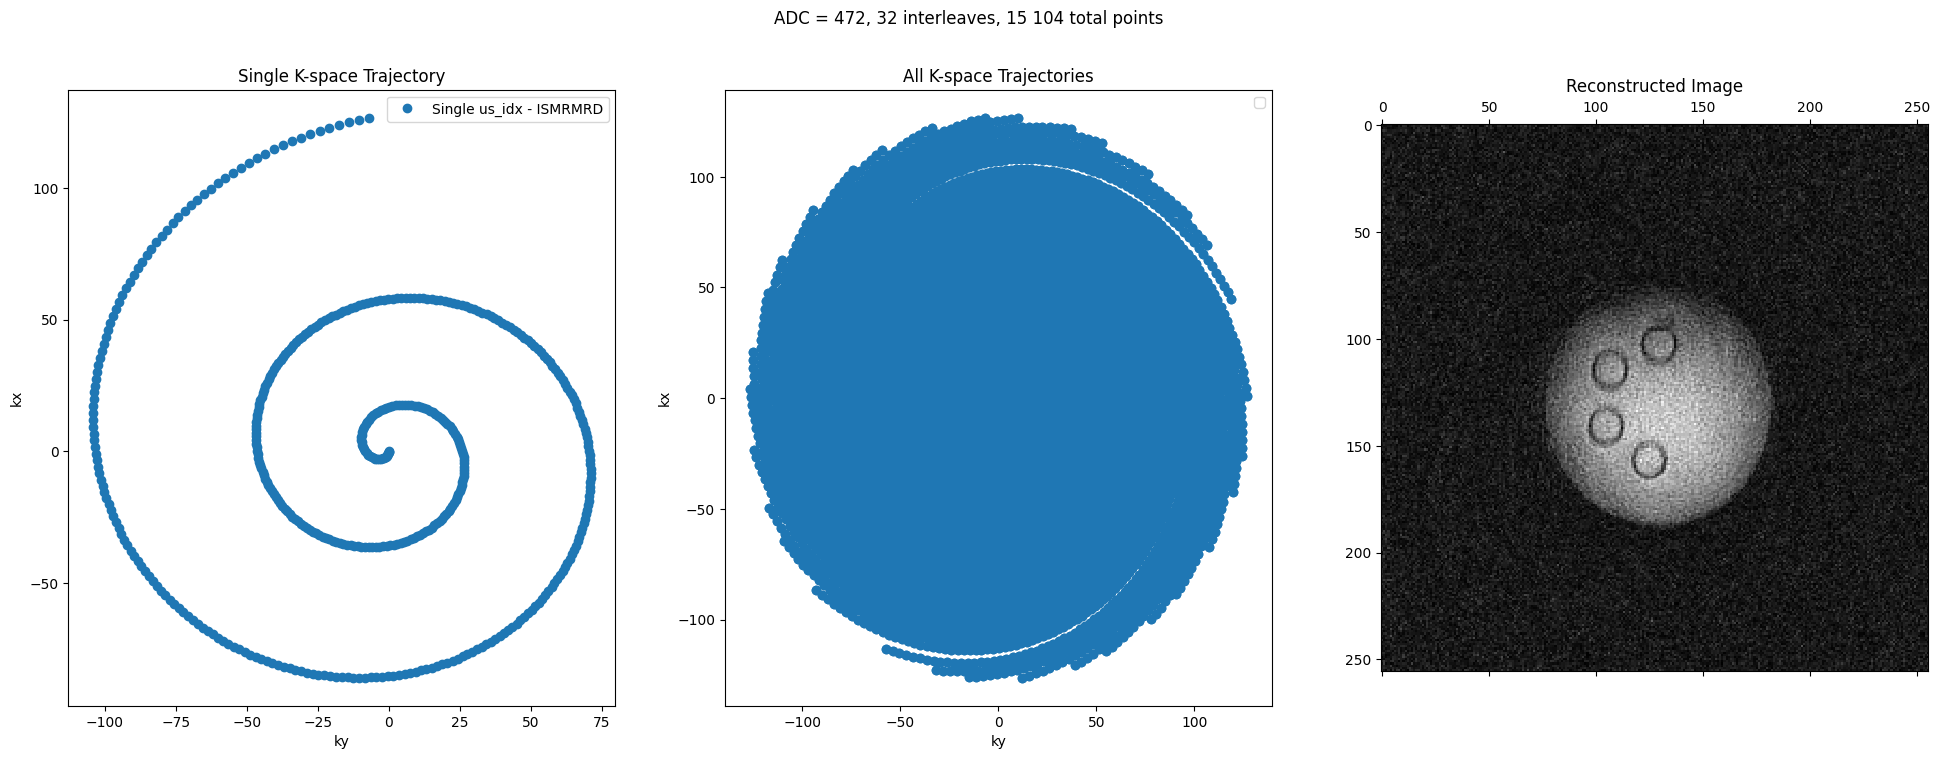

In [9]:
# Load data from ISMRMRD file using KTrajectoryIsmrmrd
kdata_ismrmrd = KData.from_file(h5_path1, KTrajectoryIsmrmrd())
kdata_ismrmrd.header.recon_matrix = SpatialDimension(z=1, y=256, x=256)
kdata_ismrmrd.header.encoding_matrix = SpatialDimension(z=1, y=256, x=256)

# Perform the reconstruction
reconstruction_ismrmrd = mrpro.algorithms.reconstruction.DirectReconstruction.from_kdata(kdata_ismrmrd)
img = reconstruction_ismrmrd(kdata_ismrmrd)

# Display the reconstructed image
# If there are multiple slices, only the first one is selected
first_img = img.rss().cpu()[0, 0, :, :]  # images, z, y, x

# Define values to compare for us_idx
us_idx_values = [torch.arange(0, 8, 139)[None, :]]

# Create a figure with three subplots: one for a single trajectory, one for all trajectories, and one for the image
fig, axes = plt.subplots(1, 3, figsize=(24, 8))
fig.suptitle('ADC = 472, 32 interleaves, 15 104 total points')
# Plot a single k-space trajectory for the first us_idx value on the first subplot
ax1 = axes[0]
single_us_idx = us_idx_values[0]
print(f"Calculating for single us_idx:", single_us_idx)

# Split k-space data into other dimensions based on undersampling indices
kdata_us_single = kdata_ismrmrd.split_k1_into_other(single_us_idx, other_label='repetition')

# Plot single k-space trajectory for ISMRMRD
ax1.plot(kdata_us_single.traj.ky.flatten(), kdata_us_single.traj.kx.flatten(), 'o', label='Single us_idx - ISMRMRD')
ax1.set_xlabel('ky')
ax1.set_ylabel('kx')
ax1.set_title('Single K-space Trajectory')
ax1.legend()

# Plot k-space trajectories for all us_idx values on the second subplot
ax2 = axes[1]
# Plot k-space trajectory for ISMRMRD
ax2.plot(kdata_ismrmrd.traj.ky.flatten(), kdata_ismrmrd.traj.kx.flatten(), 'o')

ax2.set_xlabel('ky')
ax2.set_ylabel('kx')
ax2.set_title('All K-space Trajectories')
ax2.legend()

# Plot the reconstructed image on the third subplot
ax3 = axes[2]
ax3.matshow(first_img, cmap='gray')
ax3.set_title('Reconstructed Image')

# Display the combined figure
plt.show()

### Acquisition 2

Calculating for single us_idx: tensor([[0]])


/tmp/ipykernel_2530/2877647798.py:43: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()


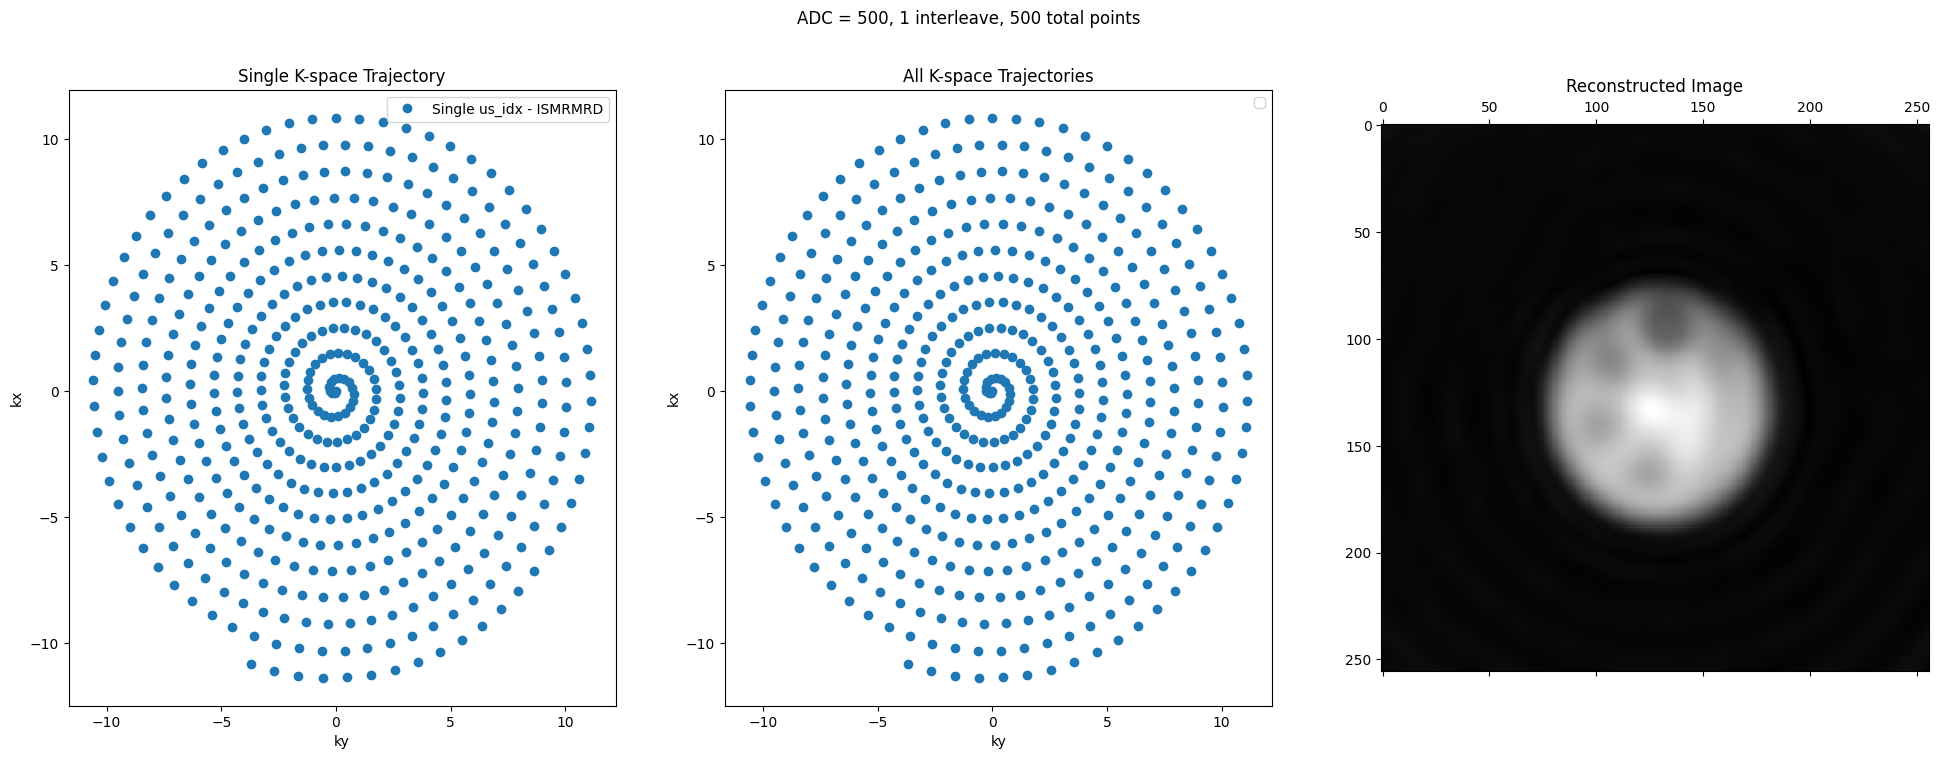

In [10]:
# Load data from ISMRMRD file using KTrajectoryIsmrmrd
kdata_ismrmrd = KData.from_file(h5_path2, KTrajectoryIsmrmrd())
kdata_ismrmrd.header.recon_matrix = SpatialDimension(z=1, y=256, x=256)
kdata_ismrmrd.header.encoding_matrix = SpatialDimension(z=1, y=256, x=256)

# Perform the reconstruction
reconstruction_ismrmrd = mrpro.algorithms.reconstruction.DirectReconstruction.from_kdata(kdata_ismrmrd)
img = reconstruction_ismrmrd(kdata_ismrmrd)

# Display the reconstructed image
# If there are multiple slices, only the first one is selected
first_img = img.rss().cpu()[0, 0, :, :]  # images, z, y, x

# Define values to compare for us_idx
us_idx_values = [torch.arange(0, 8, 139)[None, :]]

# Create a figure with three subplots: one for a single trajectory, one for all trajectories, and one for the image
fig, axes = plt.subplots(1, 3, figsize=(24, 8))
fig.suptitle('ADC = 500, 1 interleave, 500 total points')
# Plot a single k-space trajectory for the first us_idx value on the first subplot
ax1 = axes[0]
single_us_idx = us_idx_values[0]
print(f"Calculating for single us_idx:", single_us_idx)

# Split k-space data into other dimensions based on undersampling indices
kdata_us_single = kdata_ismrmrd.split_k1_into_other(single_us_idx, other_label='repetition')

# Plot single k-space trajectory for ISMRMRD
ax1.plot(kdata_us_single.traj.ky.flatten(), kdata_us_single.traj.kx.flatten(), 'o', label='Single us_idx - ISMRMRD')
ax1.set_xlabel('ky')
ax1.set_ylabel('kx')
ax1.set_title('Single K-space Trajectory')
ax1.legend()

# Plot k-space trajectories for all us_idx values on the second subplot
ax2 = axes[1]
# Plot k-space trajectory for ISMRMRD
ax2.plot(kdata_ismrmrd.traj.ky.flatten(), kdata_ismrmrd.traj.kx.flatten(), 'o')

ax2.set_xlabel('ky')
ax2.set_ylabel('kx')
ax2.set_title('All K-space Trajectories')
ax2.legend()

# Plot the reconstructed image on the third subplot
ax3 = axes[2]
ax3.matshow(first_img, cmap='gray')
ax3.set_title('Reconstructed Image')

# Display the combined figure
plt.show()

### Acquisition 3

Calculating for single us_idx: tensor([[0]])


/tmp/ipykernel_2530/1855608429.py:43: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()


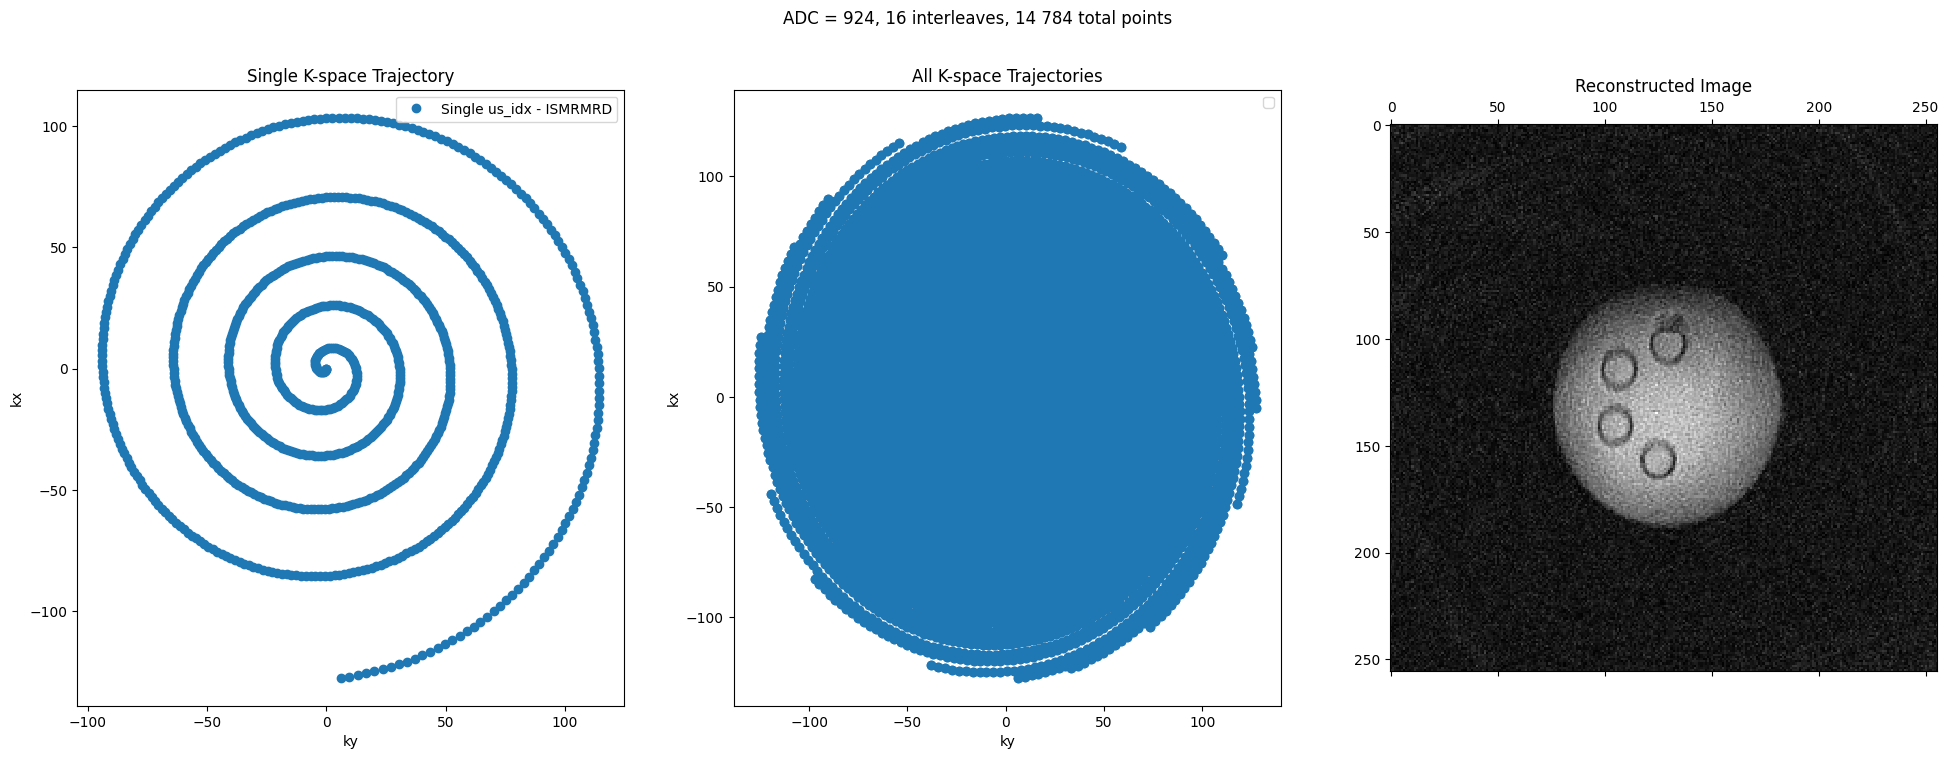

In [11]:
# Load data from ISMRMRD file using KTrajectoryIsmrmrd
kdata_ismrmrd = KData.from_file(h5_path3, KTrajectoryIsmrmrd())
kdata_ismrmrd.header.recon_matrix = SpatialDimension(z=1, y=256, x=256)
kdata_ismrmrd.header.encoding_matrix = SpatialDimension(z=1, y=256, x=256)

# Perform the reconstruction
reconstruction_ismrmrd = mrpro.algorithms.reconstruction.DirectReconstruction.from_kdata(kdata_ismrmrd)
img = reconstruction_ismrmrd(kdata_ismrmrd)

# Display the reconstructed image
# If there are multiple slices, only the first one is selected
first_img = img.rss().cpu()[0, 0, :, :]  # images, z, y, x

# Define values to compare for us_idx
us_idx_values = [torch.arange(0, 8, 139)[None, :]]

# Create a figure with three subplots: one for a single trajectory, one for all trajectories, and one for the image
fig, axes = plt.subplots(1, 3, figsize=(24, 8))
fig.suptitle('ADC = 924, 16 interleaves, 14 784 total points')
# Plot a single k-space trajectory for the first us_idx value on the first subplot
ax1 = axes[0]
single_us_idx = us_idx_values[0]
print(f"Calculating for single us_idx:", single_us_idx)

# Split k-space data into other dimensions based on undersampling indices
kdata_us_single = kdata_ismrmrd.split_k1_into_other(single_us_idx, other_label='repetition')

# Plot single k-space trajectory for ISMRMRD
ax1.plot(kdata_us_single.traj.ky.flatten(), kdata_us_single.traj.kx.flatten(), 'o', label='Single us_idx - ISMRMRD')
ax1.set_xlabel('ky')
ax1.set_ylabel('kx')
ax1.set_title('Single K-space Trajectory')
ax1.legend()

# Plot k-space trajectories for all us_idx values on the second subplot
ax2 = axes[1]
# Plot k-space trajectory for ISMRMRD
ax2.plot(kdata_ismrmrd.traj.ky.flatten(), kdata_ismrmrd.traj.kx.flatten(), 'o')

ax2.set_xlabel('ky')
ax2.set_ylabel('kx')
ax2.set_title('All K-space Trajectories')
ax2.legend()

# Plot the reconstructed image on the third subplot
ax3 = axes[2]
ax3.matshow(first_img, cmap='gray')
ax3.set_title('Reconstructed Image')

# Display the combined figure
plt.show()

### Acquisition 4

Calculating for single us_idx: tensor([[0]])


/tmp/ipykernel_2530/3879704437.py:43: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()


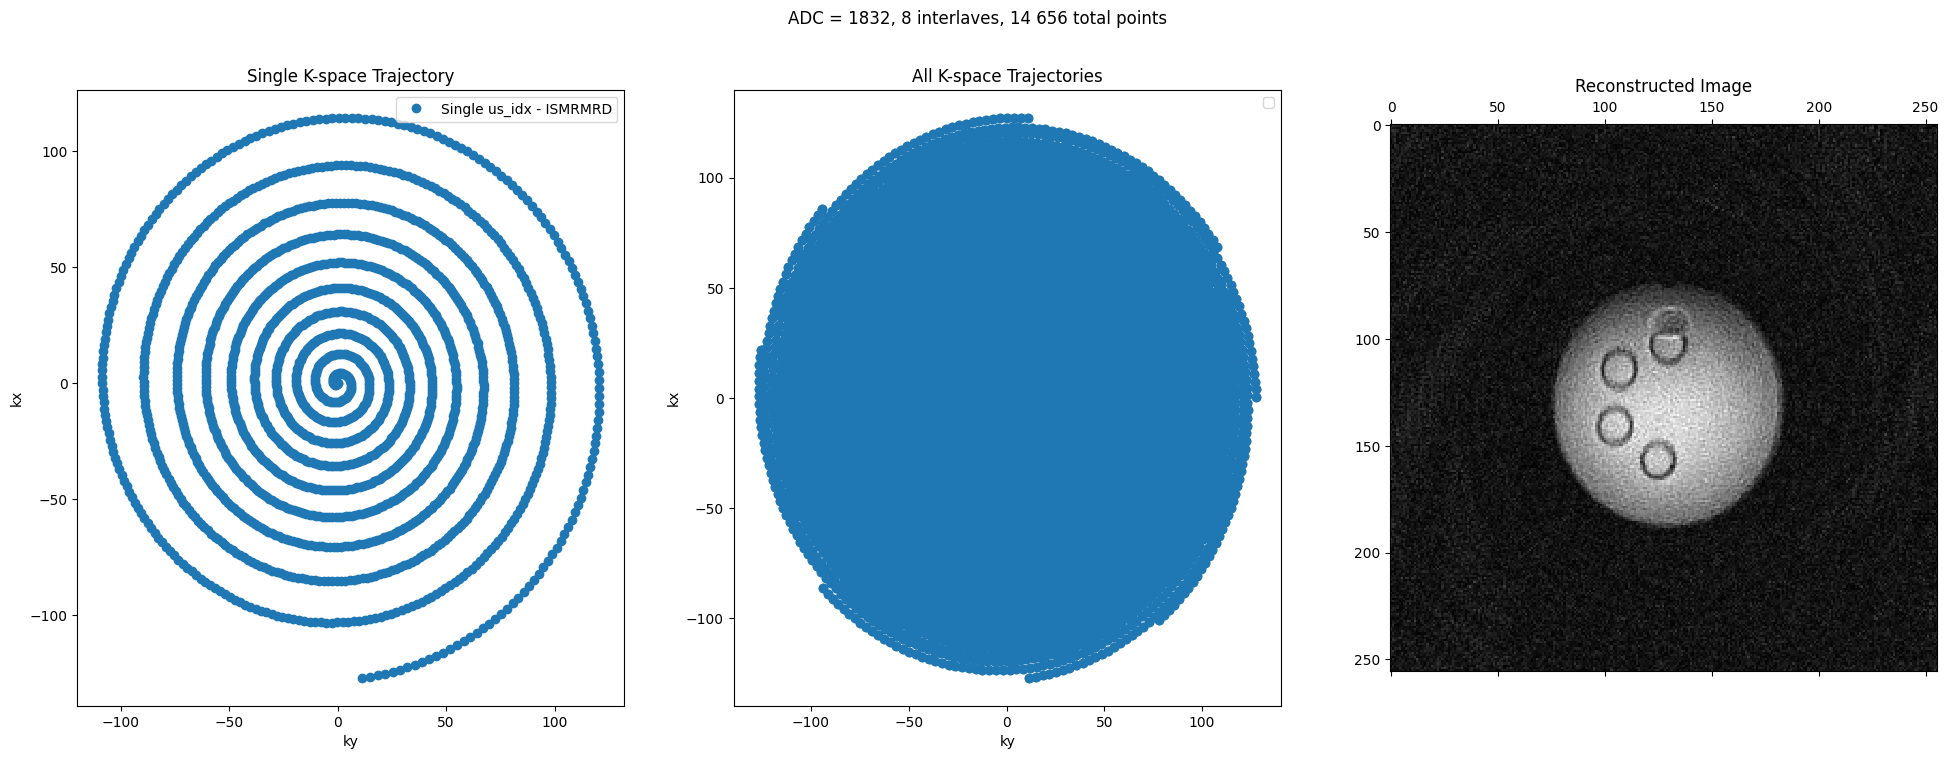

In [12]:
# Load data from ISMRMRD file using KTrajectoryIsmrmrd
kdata_ismrmrd = KData.from_file(h5_path4, KTrajectoryIsmrmrd())
kdata_ismrmrd.header.recon_matrix = SpatialDimension(z=1, y=256, x=256)
kdata_ismrmrd.header.encoding_matrix = SpatialDimension(z=1, y=256, x=256)

# Perform the reconstruction
reconstruction_ismrmrd = mrpro.algorithms.reconstruction.DirectReconstruction.from_kdata(kdata_ismrmrd)
img = reconstruction_ismrmrd(kdata_ismrmrd)

# Display the reconstructed image
# If there are multiple slices, only the first one is selected
first_img = img.rss().cpu()[0, 0, :, :]  # images, z, y, x

# Define values to compare for us_idx
us_idx_values = [torch.arange(0, 8, 139)[None, :]]

# Create a figure with three subplots: one for a single trajectory, one for all trajectories, and one for the image
fig, axes = plt.subplots(1, 3, figsize=(24, 8))
fig.suptitle('ADC = 1832, 8 interlaves, 14 656 total points')
# Plot a single k-space trajectory for the first us_idx value on the first subplot
ax1 = axes[0]
single_us_idx = us_idx_values[0]
print(f"Calculating for single us_idx:", single_us_idx)

# Split k-space data into other dimensions based on undersampling indices
kdata_us_single = kdata_ismrmrd.split_k1_into_other(single_us_idx, other_label='repetition')

# Plot single k-space trajectory for ISMRMRD
ax1.plot(kdata_us_single.traj.ky.flatten(), kdata_us_single.traj.kx.flatten(), 'o', label='Single us_idx - ISMRMRD')
ax1.set_xlabel('ky')
ax1.set_ylabel('kx')
ax1.set_title('Single K-space Trajectory')
ax1.legend()

# Plot k-space trajectories for all us_idx values on the second subplot
ax2 = axes[1]
# Plot k-space trajectory for ISMRMRD
ax2.plot(kdata_ismrmrd.traj.ky.flatten(), kdata_ismrmrd.traj.kx.flatten(), 'o')

ax2.set_xlabel('ky')
ax2.set_ylabel('kx')
ax2.set_title('All K-space Trajectories')
ax2.legend()

# Plot the reconstructed image on the third subplot
ax3 = axes[2]
ax3.matshow(first_img, cmap='gray')
ax3.set_title('Reconstructed Image')

# Display the combined figure
plt.show()

### Acquisition 5

Calculating for single us_idx: tensor([[0]])


/tmp/ipykernel_2530/2602332123.py:43: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()


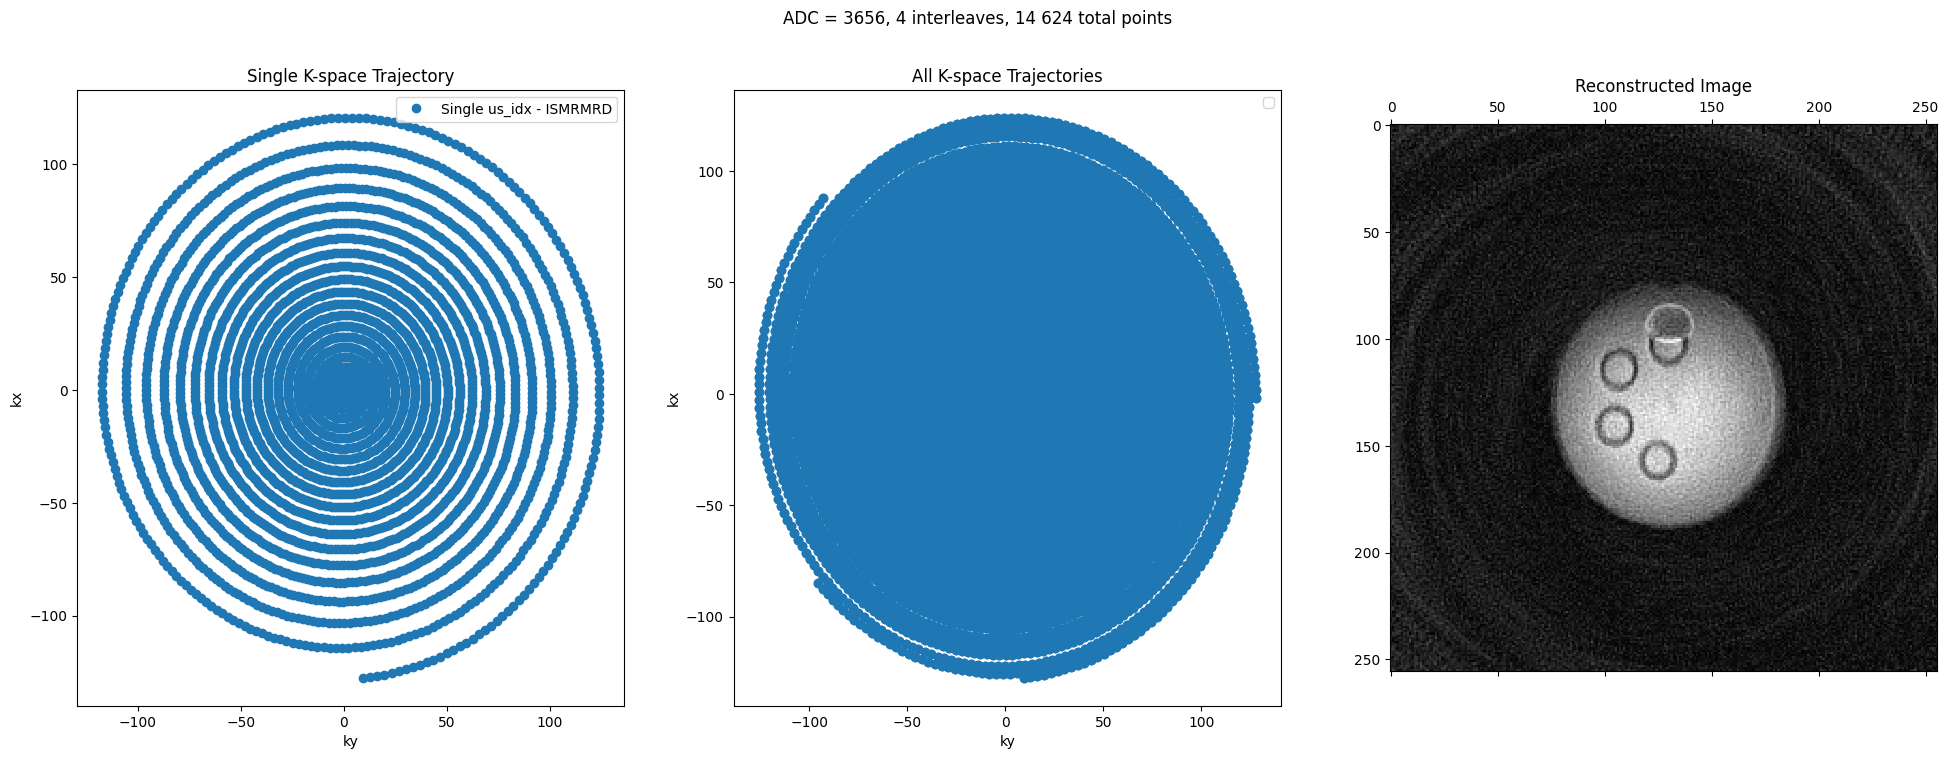

In [13]:
# Load data from ISMRMRD file using KTrajectoryIsmrmrd
kdata_ismrmrd = KData.from_file(h5_path5, KTrajectoryIsmrmrd())
kdata_ismrmrd.header.recon_matrix = SpatialDimension(z=1, y=256, x=256)
kdata_ismrmrd.header.encoding_matrix = SpatialDimension(z=1, y=256, x=256)

# Perform the reconstruction
reconstruction_ismrmrd = mrpro.algorithms.reconstruction.DirectReconstruction.from_kdata(kdata_ismrmrd)
img = reconstruction_ismrmrd(kdata_ismrmrd)

# Display the reconstructed image
# If there are multiple slices, only the first one is selected
first_img = img.rss().cpu()[0, 0, :, :]  # images, z, y, x

# Define values to compare for us_idx
us_idx_values = [torch.arange(0, 8, 139)[None, :]]

# Create a figure with three subplots: one for a single trajectory, one for all trajectories, and one for the image
fig, axes = plt.subplots(1, 3, figsize=(24, 8))
fig.suptitle('ADC = 3656, 4 interleaves, 14 624 total points')
# Plot a single k-space trajectory for the first us_idx value on the first subplot
ax1 = axes[0]
single_us_idx = us_idx_values[0]
print(f"Calculating for single us_idx:", single_us_idx)

# Split k-space data into other dimensions based on undersampling indices
kdata_us_single = kdata_ismrmrd.split_k1_into_other(single_us_idx, other_label='repetition')

# Plot single k-space trajectory for ISMRMRD
ax1.plot(kdata_us_single.traj.ky.flatten(), kdata_us_single.traj.kx.flatten(), 'o', label='Single us_idx - ISMRMRD')
ax1.set_xlabel('ky')
ax1.set_ylabel('kx')
ax1.set_title('Single K-space Trajectory')
ax1.legend()

# Plot k-space trajectories for all us_idx values on the second subplot
ax2 = axes[1]
# Plot k-space trajectory for ISMRMRD
ax2.plot(kdata_ismrmrd.traj.ky.flatten(), kdata_ismrmrd.traj.kx.flatten(), 'o')

ax2.set_xlabel('ky')
ax2.set_ylabel('kx')
ax2.set_title('All K-space Trajectories')
ax2.legend()

# Plot the reconstructed image on the third subplot
ax3 = axes[2]
ax3.matshow(first_img, cmap='gray')
ax3.set_title('Reconstructed Image')

# Display the combined figure
plt.show()

### Acquisition 6 

Calculating for single us_idx: tensor([[0]])


/tmp/ipykernel_2530/3167882889.py:43: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()


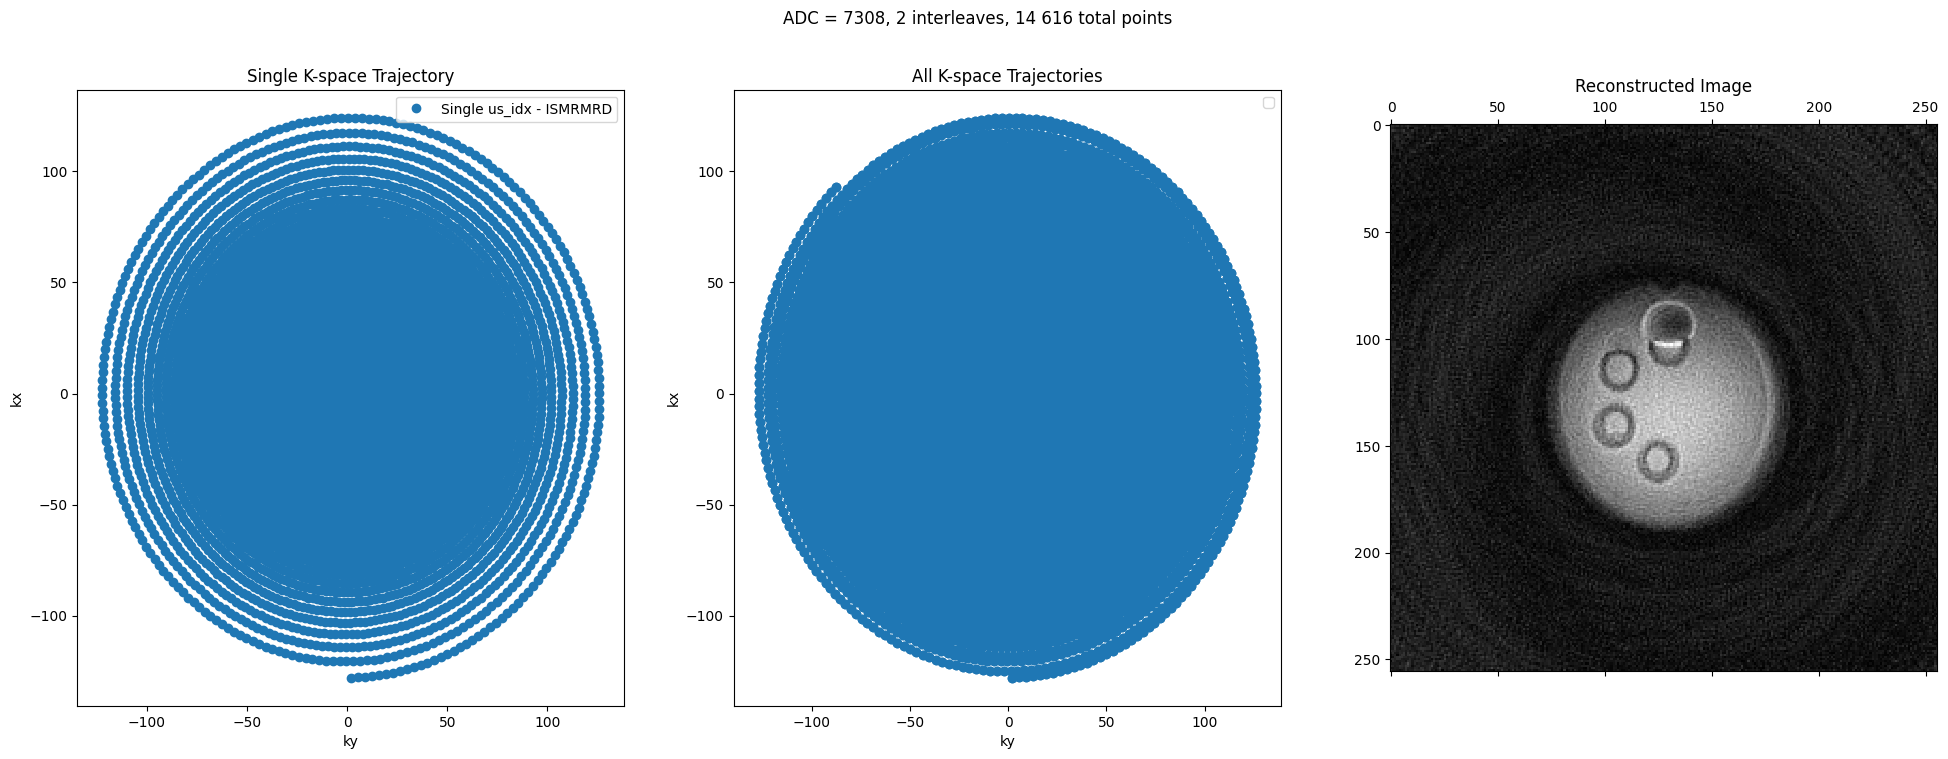

In [14]:
# Load data from ISMRMRD file using KTrajectoryIsmrmrd
kdata_ismrmrd = KData.from_file(h5_path6, KTrajectoryIsmrmrd())
kdata_ismrmrd.header.recon_matrix = SpatialDimension(z=1, y=256, x=256)
kdata_ismrmrd.header.encoding_matrix = SpatialDimension(z=1, y=256, x=256)

# Perform the reconstruction
reconstruction_ismrmrd = mrpro.algorithms.reconstruction.DirectReconstruction.from_kdata(kdata_ismrmrd)
img = reconstruction_ismrmrd(kdata_ismrmrd)

# Display the reconstructed image
# If there are multiple slices, only the first one is selected
first_img = img.rss().cpu()[0, 0, :, :]  # images, z, y, x

# Define values to compare for us_idx
us_idx_values = [torch.arange(0, 8, 139)[None, :]]

# Create a figure with three subplots: one for a single trajectory, one for all trajectories, and one for the image
fig, axes = plt.subplots(1, 3, figsize=(24, 8))
fig.suptitle('ADC = 7308, 2 interleaves, 14 616 total points')
# Plot a single k-space trajectory for the first us_idx value on the first subplot
ax1 = axes[0]
single_us_idx = us_idx_values[0]
print(f"Calculating for single us_idx:", single_us_idx)

# Split k-space data into other dimensions based on undersampling indices
kdata_us_single = kdata_ismrmrd.split_k1_into_other(single_us_idx, other_label='repetition')

# Plot single k-space trajectory for ISMRMRD
ax1.plot(kdata_us_single.traj.ky.flatten(), kdata_us_single.traj.kx.flatten(), 'o', label='Single us_idx - ISMRMRD')
ax1.set_xlabel('ky')
ax1.set_ylabel('kx')
ax1.set_title('Single K-space Trajectory')
ax1.legend()

# Plot k-space trajectories for all us_idx values on the second subplot
ax2 = axes[1]
# Plot k-space trajectory for ISMRMRD
ax2.plot(kdata_ismrmrd.traj.ky.flatten(), kdata_ismrmrd.traj.kx.flatten(), 'o')

ax2.set_xlabel('ky')
ax2.set_ylabel('kx')
ax2.set_title('All K-space Trajectories')
ax2.legend()

# Plot the reconstructed image on the third subplot
ax3 = axes[2]
ax3.matshow(first_img, cmap='gray')
ax3.set_title('Reconstructed Image')

# Display the combined figure
plt.show()